# **Project Name**    - Most Streamed Spotify Songs 2023



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**   - Bhumika Maheshwari


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/bhumika0205/Spotify-EDA

# **Problem Statement**


The music industry generates massive amounts of streaming data every day. Understanding the characteristics of highly streamed songs can help artists, producers, and streaming platforms identify trends that contribute to a song's popularity.

This project aims to analyze the Spotify 2023 dataset to discover relationships between song popularity, artist performance, release patterns, playlist appearances, chart rankings, and musical features using exploratory data analysis techniques.

#### **Define Your Business Objective?**

The primary objectives of this project are:

- Analyze the distribution of the most streamed songs.
- Identify the most successful artists.
- Examine how release year affects streaming performance.
- Explore relationships between playlist appearances and stream counts.
- Study the influence of musical attributes such as danceability, energy, valence, and tempo.
- Generate meaningful visualizations to support business insights.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ***1. Know Your Data***

### Import Libraries

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

### Dataset Loading

In [6]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/spotify-2023.csv",
    encoding="latin-1"
)

### Dataset First View

In [7]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


### Dataset Rows & Columns count

In [8]:
df.shape

(953, 24)

### Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

#### Duplicate Values

In [10]:
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [11]:
df.isnull().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


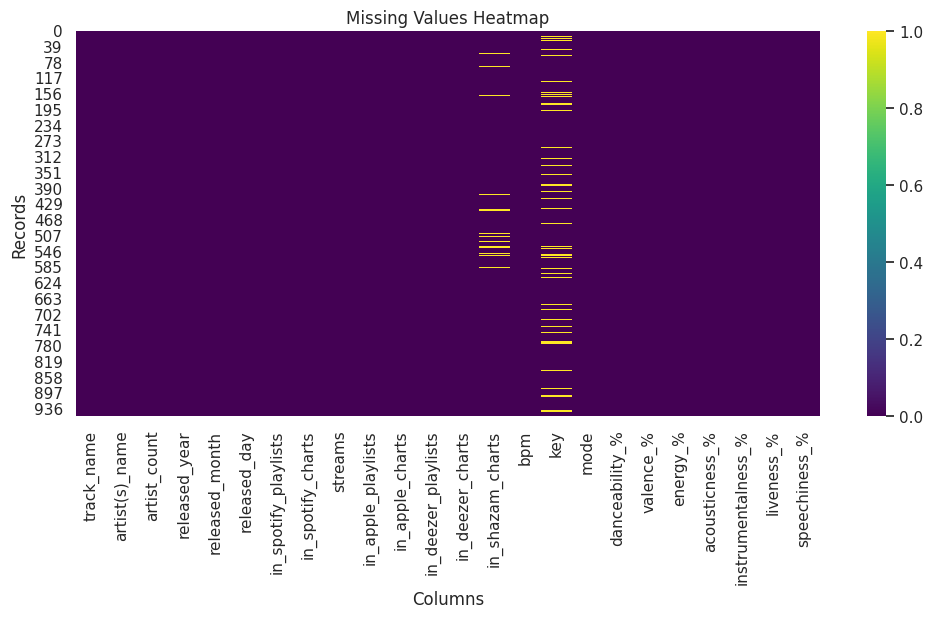

In [12]:
# Visualizing the missing values

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.show()

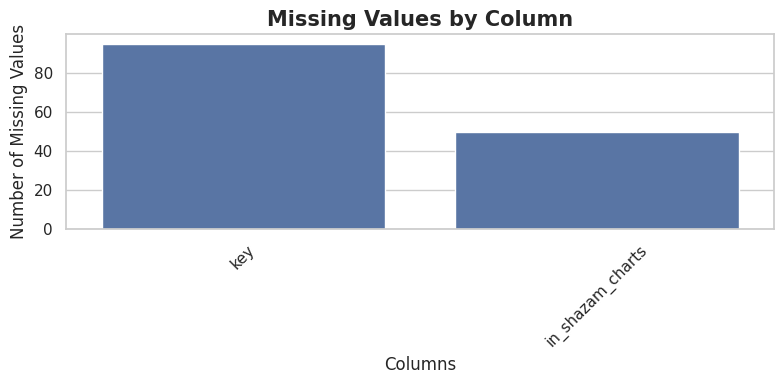

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Missing Values by Column", fontsize=15, weight="bold")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### What did you know about your dataset?

- The dataset contains **953 songs** and **24 features**, with each row representing a unique song.
- It includes a combination of **categorical** (song name, artist name, key, mode) and **numerical** (streams, playlist counts, chart rankings, musical attributes) variables.
- The data provides information about song popularity across various streaming platforms and playlists, along with audio characteristics such as danceability, energy, valence, speechiness, and tempo.
- Initial inspection indicates that the dataset is largely complete, with only a small number of missing values in a few columns.
- No duplicate records were found, suggesting that each observation represents a distinct song.
- Some columns, such as **`streams`**, are stored as the **object** data type instead of numeric and will require data type conversion before performing statistical analysis.
- Overall, the dataset is well-structured and requires only minimal preprocessing before exploratory data analysis.

## ***2. Understanding Your Variables***

In [14]:
df.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [15]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


### Variables Description

* **track_name** : Name of the song
* **artist(s)_name** : Name of the artist(s) of the song
* **artist_count** : Number of artists contributing to the song
* **released_year** : Year when the song was released
* **released_month** : Month when the song was released
* **released_day** : Day of the month when the song was released
* **in_spotify_playlists** : Number of Spotify playlists the song is included in
* **in_spotify_charts** : Presence and rank of the song on Spotify charts
* **streams** : Total number of streams on Spotify
* **in_apple_playlists** : Number of Apple Music playlists the song is included in
* **in_apple_charts** : Presence and rank of the song on Apple Music charts
* **in_deezer_playlists** : Number of Deezer playlists the song is included in
* **in_deezer_charts** : Presence and rank of the song on Deezer charts
* **in_shazam_charts** : Presence and rank of the song on Shazam charts
* **bpm** : Beats per minute, a measure of song tempo
* **key** : Key of the song
* **mode** : Mode of the song (major or minor)
* **danceability_%** : Percentage indicating how suitable the song is for dancing
* **valence_%** : Positivity of the song's musical content
* **energy_%** : Perceived energy level of the song
* **acousticness_%** : Amount of acoustic sound in the song
* **instrumentalness_%** : Amount of instrumental content in the song
* **liveness_%** : Presence of live performance elements
* **speechiness_%** : Amount of spoken words in the song

### Check Unique Values for each variable.

In [ ]:
df.nunique()

,0
track_name,943
artist(s)_name,645
artist_count,8
released_year,50
released_month,12
released_day,31
in_spotify_playlists,879
in_spotify_charts,82
streams,949
in_apple_playlists,234


## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
df_clean = df.copy()

In [19]:
#checking for duplicate records
duplicate_count = df_clean.duplicated().sum()
print("Duplicate Records:", duplicate_count)

Duplicate Records: 0


In [21]:
#checking for missing data
missing_values = df_clean.isnull().sum()
missing_values[missing_values > 0]

,0
in_shazam_charts,50
key,95


In [24]:
# Fill missing values in 'key' with the mode since it is a categorical column
df_clean["key"] = df_clean["key"].fillna(df_clean["key"].mode()[0])

In [36]:
# Converting 'in_shazam_charts' from object to numeric
df_clean["in_shazam_charts"] = pd.to_numeric(
    df_clean["in_shazam_charts"],
    errors="coerce"
)

In [35]:
# Convert "in_shazam_charts" to integer
df_clean["in_shazam_charts"] = df_clean["in_shazam_charts"].fillna(0)
df_clean["in_shazam_charts"] = df_clean["in_shazam_charts"].astype(int)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      953 non-null    int64 
 14  bpm                   953 non-null    int64 
 15  key                   953 non-null    ob

In [41]:
#checking if any 'streams' is null value
pd.to_numeric(df_clean["streams"], errors="coerce").isnull().sum()

np.int64(0)

In [39]:
# Remove the corrupted row with an invalid stream value
df_clean = df_clean[
    pd.to_numeric(df_clean["streams"], errors="coerce").notnull()
]

# Convert the streams column to numeric
df_clean["streams"] = pd.to_numeric(df_clean["streams"])

In [45]:
#removing ',' from "in_deezer_playlists" and converting to int data type
df_clean["in_deezer_playlists"] = (
    df_clean["in_deezer_playlists"]
    .str.replace(",", "", regex=False)
)

df_clean["in_deezer_playlists"] = pd.to_numeric(
    df_clean["in_deezer_playlists"]
)

In [47]:
# Final verification of cleaned dataset
df_clean.info()
print("Dataset Shape:", df_clean.shape)
print("\nMissing Values:\n")
print(df_clean.isnull().sum())
print("\nDuplicate Records:", df_clean.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            952 non-null    object
 1   artist(s)_name        952 non-null    object
 2   artist_count          952 non-null    int64 
 3   released_year         952 non-null    int64 
 4   released_month        952 non-null    int64 
 5   released_day          952 non-null    int64 
 6   in_spotify_playlists  952 non-null    int64 
 7   in_spotify_charts     952 non-null    int64 
 8   streams               952 non-null    int64 
 9   in_apple_playlists    952 non-null    int64 
 10  in_apple_charts       952 non-null    int64 
 11  in_deezer_playlists   952 non-null    int64 
 12  in_deezer_charts      952 non-null    int64 
 13  in_shazam_charts      952 non-null    int64 
 14  bpm                   952 non-null    int64 
 15  key                   952 non-null    object


### What all manipulations have you done and insights you found?

* Created a working copy of the original dataset to preserve the raw data.
* Verified that no duplicate records were present.
* Handled missing values in the 'key' column by replacing missing values with mode value.
* Handled missing value of 'in_shazam_charts' columns using appropriate imputation methods and converted it to int data type.
* Identified and removed one corrupted record with an invalid streams value,as it could not be converted to a numeric format.
* Converted the 'streams' and 'in_deezer_playlists' columns to the appropriate numeric data type.
* Verified that the cleaned dataset contains no missing values in the processed columns and is ready for exploratory data analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Top 10 Most streamed songs

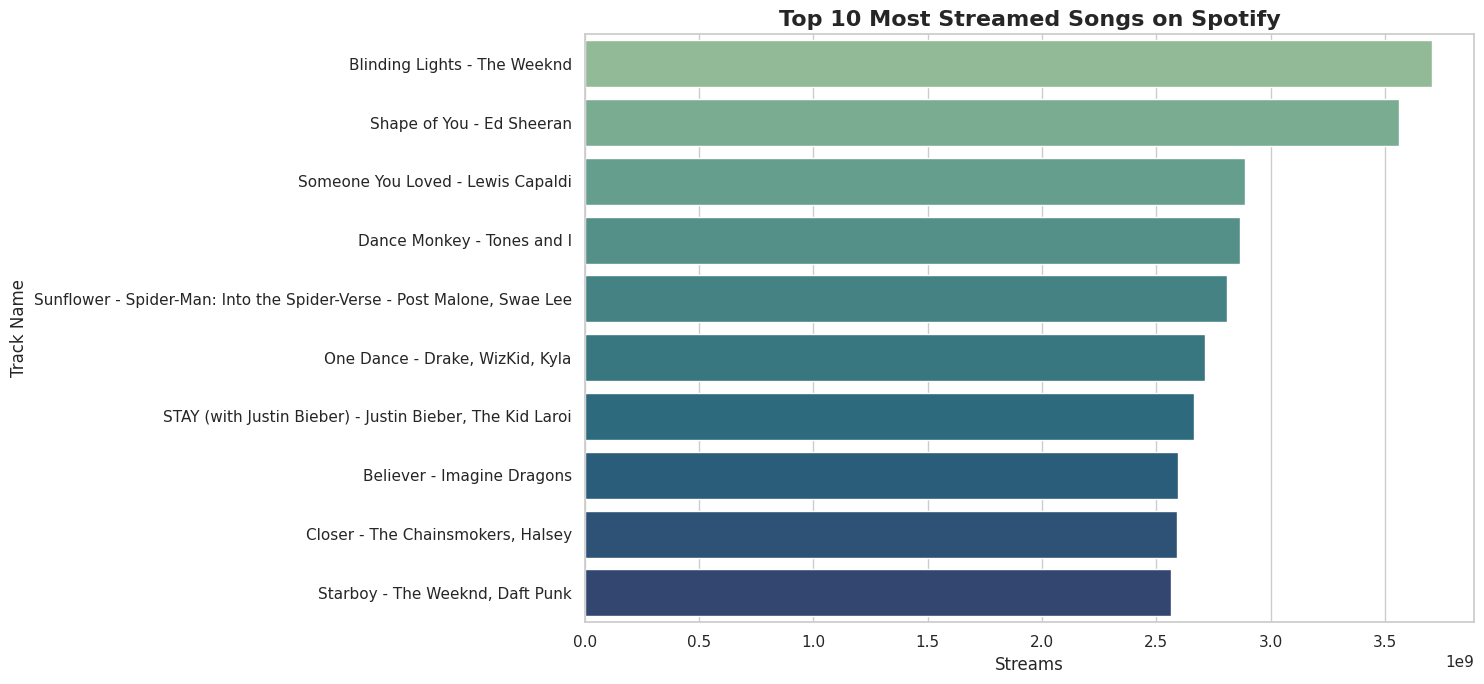

In [65]:
# Chart - 1 visualization code

# Top 10 Most streamed songs

top10_songs = df_clean.sort_values(by="streams", ascending=False).head(10)
top10_songs["Song"] = (
    top10_songs["track_name"] +
    " - " +
    top10_songs["artist(s)_name"]
)

plt.figure(figsize=(15,7))

sns.barplot(
    data=top10_songs,
    x="streams",
    y="Song",
    hue="track_name",
    palette="crest",
    legend=False
)

plt.title("Top 10 Most Streamed Songs on Spotify", fontsize=16, fontweight="bold")
plt.xlabel("Streams", fontsize=12)
plt.ylabel("Track Name", fontsize=12)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it is the most effective way to compare the stream counts of the top 10 songs. Since song titles can be long, a horizontal layout provides better readability than a vertical bar chart. It also allows viewers to quickly identify and compare the highest-streamed songs without label overlap.

##### 2. What is/are the insight(s) found from the chart?

Insights
* A small number of songs dominate total Spotify streams, indicating that streaming popularity is highly concentrated among a few tracks.
* The difference in stream counts between the highest-ranked and lower-ranked songs in the top 10 highlights varying levels of audience engagement.
* The most-streamed songs have achieved billions of streams, reflecting their global popularity and long-term listener retention.
* These songs can be considered benchmark tracks for understanding successful music trends on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights help identify the songs that generate the highest listener engagement. Spotify can use this information to improve playlist recommendations, promote similar artists, enhance personalized music suggestions, and support marketing campaigns. Record labels can also study the characteristics of these successful songs to understand listener preferences and improve future music releases.

#### Chart - 2 Top 10 Most streamed artists

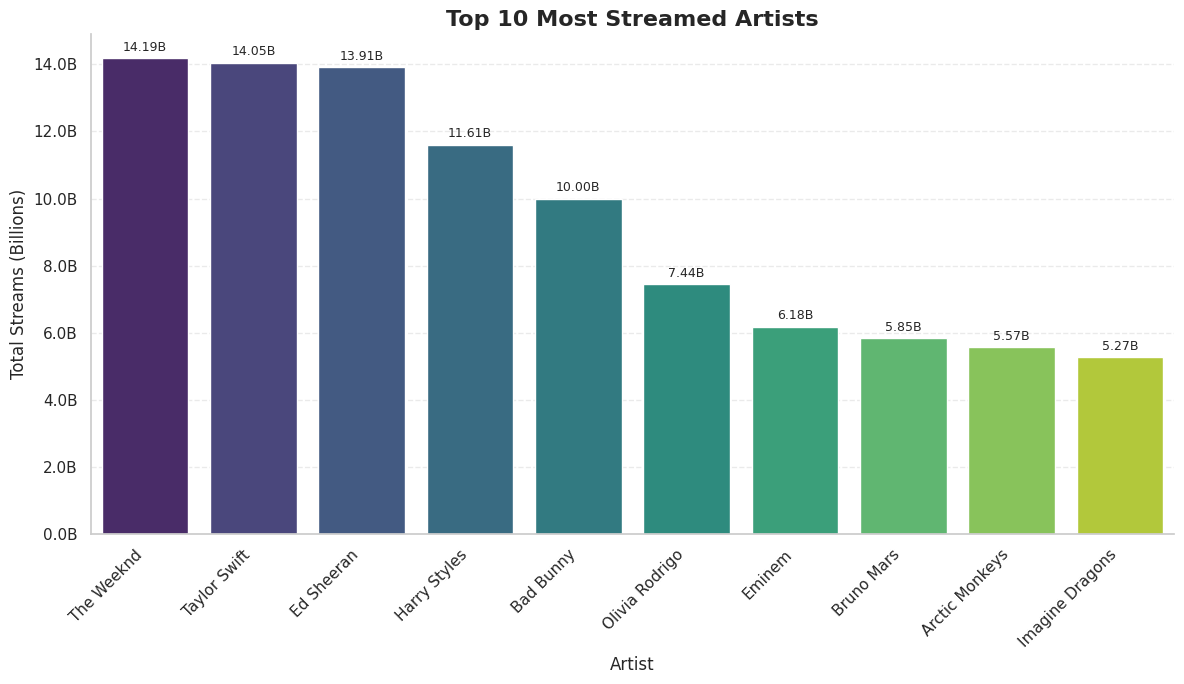

In [68]:
# Chart - 2 visualization code

# Top 10 Most Streamed Artists

top_artists = (
    df_clean.groupby("artist(s)_name")["streams"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_artists.index,
    y=top_artists.values,
    hue=top_artists.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Most Streamed Artists",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Artist", fontsize=12)
plt.ylabel("Total Streams (Billions)", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Format y-axis in billions
from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, pos: f'{x/1e9:.1f}B')
plt.gca().yaxis.set_major_formatter(formatter)

# Display values on bars
for container in ax.containers:
    labels = [f'{v.get_height()/1e9:.2f}B' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A vertical bar chart was chosen because it is the most suitable visualization for comparing the total stream counts of different artists. It clearly highlights ranking differences and allows easy comparison of artist popularity based on cumulative streams.

##### 2. What is/are the insight(s) found from the chart?

* A small number of artists contribute a significant share of the total streams, indicating their strong global popularity.
* The top-ranked artists have accumulated billions of streams, reflecting consistent listener engagement across multiple songs.
* There is a noticeable difference in stream counts between the highest-ranked artist and the remaining artists, showing that popularity is not evenly distributed.
* Artists with consistently high streams are likely to have a stronger influence on current music trends and listener preferences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positibe business impact can be this help Spotify and record labels identify artists with consistently popular music. These artists can be used for featured playlists, promotional campaigns, exclusive releases

But the chart indicates that a small number of artists dominate the dataset. Continuously promoting only these artists may reduce visibility for emerging musicians, limiting content diversity. Over time, this could decrease listener discovery of new artists and reduce the variety of music consumed on the platform.

#### Chart - 3 Top 10 artists by number of songs

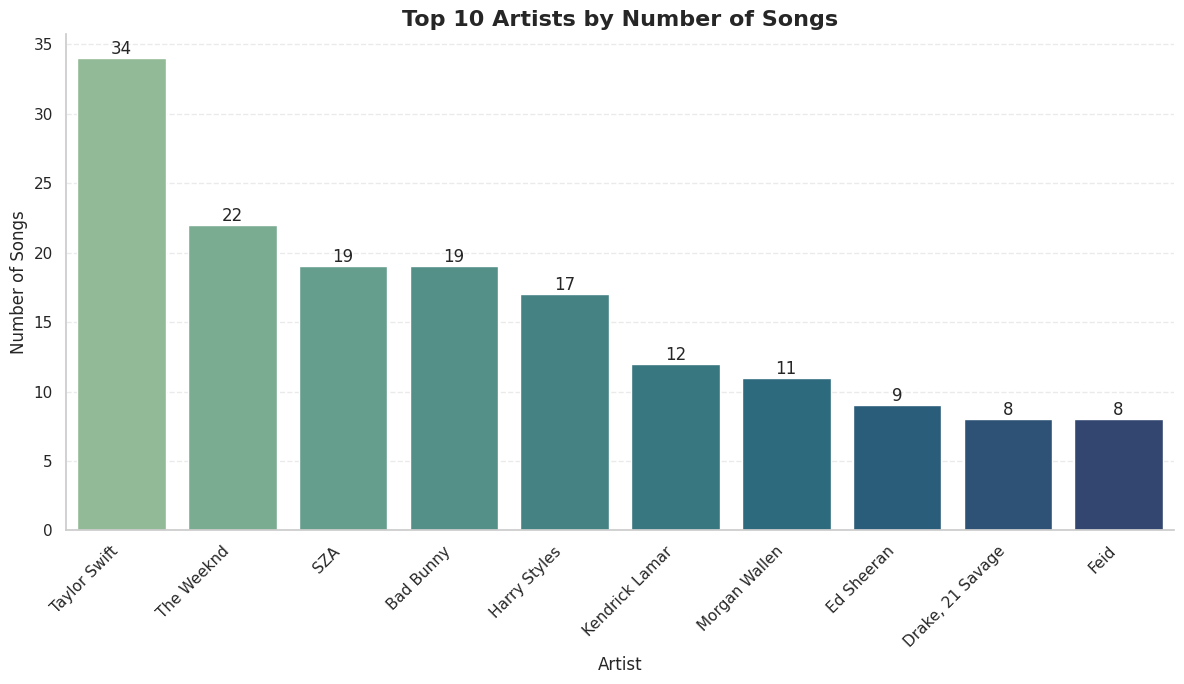

In [70]:
# Chart - 3 visualization code

# Top 10 artists by number of songs
artist_counts = df_clean["artist(s)_name"].value_counts().head(10)

plt.figure(figsize = (12, 7))

ax = sns.barplot(
    x=artist_counts.index,
    y=artist_counts.values,
    hue=artist_counts.index,
    palette="crest",
    legend=False
)

plt.title(
    "Top 10 Artists by Number of Songs",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Artist", fontsize=12)
plt.ylabel("Number of Songs", fontsize=12)

plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A vertical bar chart is ideal for comparing the number of songs contributed by different artists. Since the values represent discrete counts, bar charts make it easy to compare artists and identify those with the highest presence in the dataset.

##### 2. What is/are the insight(s) found from the chart?

* Some artists appear much more frequently in the dataset, indicating that they released multiple popular songs during the selected period.
* The distribution is uneven, with only a few artists contributing several tracks while most artists appear only once.
* A higher number of songs does not necessarily guarantee the highest total streams, suggesting that quality and audience engagement are as important as quantity.
* Artists with more songs have greater opportunities to reach listeners, but streaming success ultimately depends on how well individual tracks perform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart helps identify artists with a strong presence in the dataset. Spotify and record labels can use this information to understand which artists consistently release successful music, helping them plan playlist placements, promotional campaigns, and long-term collaborations.

The analysis shows that a few artists dominate the dataset in terms of song count. If platforms continue promoting the same artists, emerging musicians may struggle to gain visibility. This could reduce musical diversity and limit opportunities for discovering new talent.

#### Chart - 4 Which release years produced the most streams?

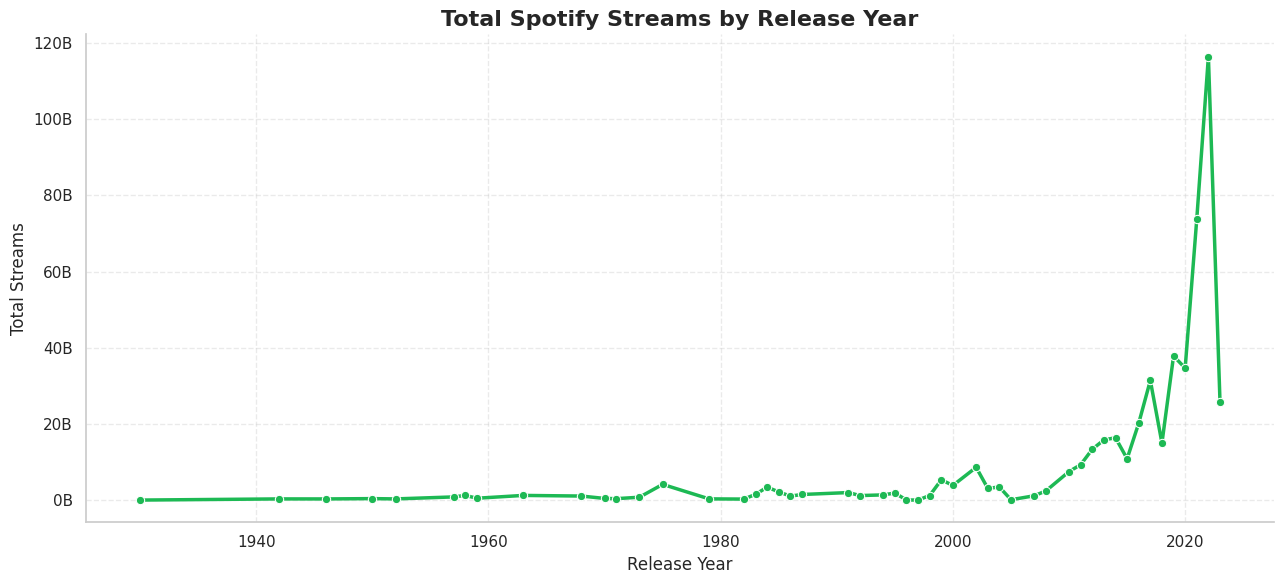

In [71]:
# Chart - 4 visualization code

# Total streams by release year

yearly_streams = (
    df_clean.groupby("released_year")["streams"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(13,6))

ax = sns.lineplot(
    x=yearly_streams.index,
    y=yearly_streams.values,
    marker="o",
    linewidth=2.5,
    color="#1DB954"
)

plt.title(
    "Total Spotify Streams by Release Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Total Streams", fontsize=12)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e9:.0f}B')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is suitable because release years are arranged in chronological order. It clearly shows how total Spotify streams vary over time, making it easier to identify trends, peaks, and changes in listener engagement across different years.

##### 2. What is/are the insight(s) found from the chart?

* Recent release years contribute a significant share of the total streams, showing that newer songs attract high listener engagement.
* Some older years still generate substantial streams due to evergreen songs that remain popular over time.
* Streaming popularity is not evenly distributed across years, indicating changing music consumption trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding which release years contribute the highest streams helps Spotify and record labels identify changing listener preferences. It can support marketing strategies, anniversary re-releases, and recommendations of both new and classic songs.

If most streams are concentrated among recent releases, older songs may receive less visibility. Conversely, if older hits dominate, newer artists may find it harder to gain attention. A balanced recommendation strategy is therefore important.

#### Chart - 5 How does playlist exposure of the top 10 streamed songs differ across Spotify, Apple Music, and Deezer?

In [73]:
# Top 10 most streamed songs
top10_playlist = (
    df_clean.sort_values(by="streams", ascending=False)
    .head(10)
)

top10_playlist["Song"] = (
    top10_playlist["track_name"] + "\n(" +
    top10_playlist["artist(s)_name"] + ")"
)

playlist_data = top10_playlist[
    [
        "Song",
        "in_spotify_playlists",
        "in_apple_playlists",
        "in_deezer_playlists"
    ]
]

playlist_data = playlist_data.set_index("Song")

<Figure size 1300x700 with 0 Axes>

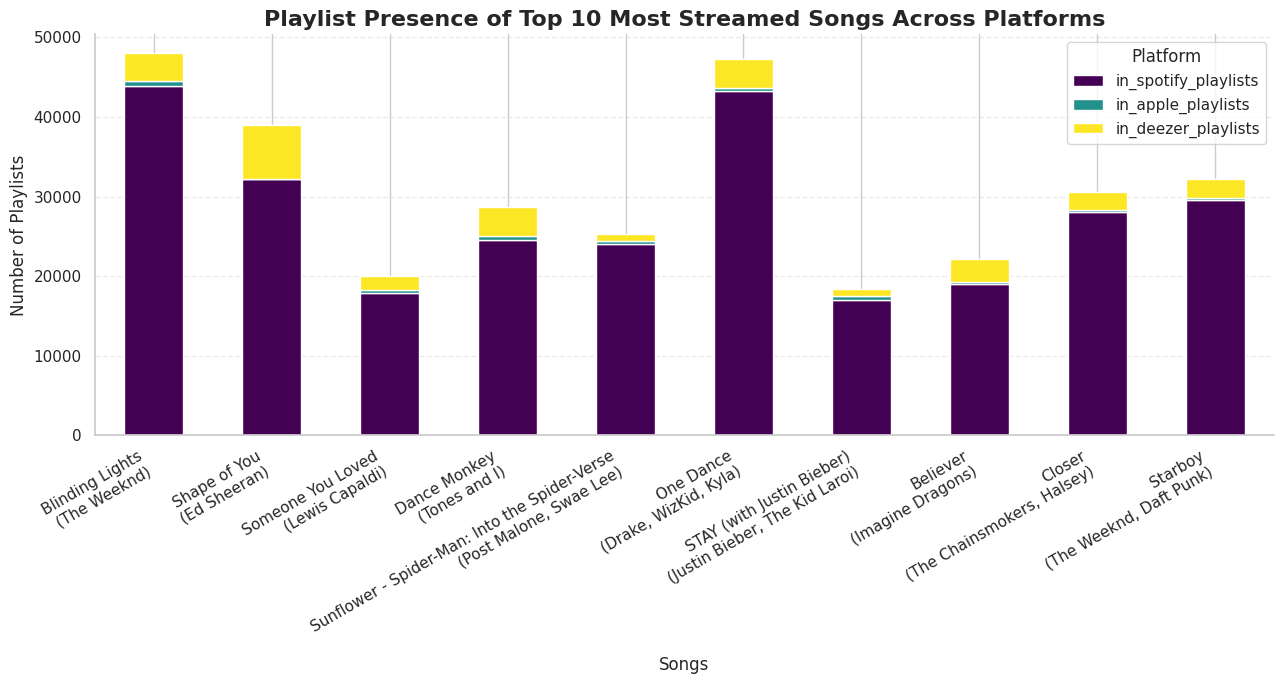

In [74]:
# Chart - 5 visualization code
# Average playlist appearances across platforms
plt.figure(figsize=(13,7))

playlist_data.plot(
    kind="bar",
    stacked=True,
    figsize=(13,7),
    colormap="viridis"
)

plt.title(
    "Playlist Presence of Top 10 Most Streamed Songs Across Platforms",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Songs")
plt.ylabel("Number of Playlists")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Platform")

sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart was chosen because it allows comparison of playlist appearances across multiple music platforms for each song in a single visualization. It clearly shows both the total playlist exposure and the contribution of Spotify, Apple Music, and Deezer, making cross-platform comparisons easier.

##### 2. What is/are the insight(s) found from the chart?

* The top streamed songs receive playlist support across all three platforms, but the level of support varies considerably.
* Spotify contributes the largest share of playlist appearances for most songs, indicating stronger playlist integration and an upperhand among all 3 streaming platforms.
* Some songs have relatively balanced playlist representation across platforms, while others rely heavily on a single platform.
* High streaming numbers are often accompanied by extensive playlist placement, suggesting that playlist exposure plays an important role in increasing song popularity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis shows that playlist exposure plays an important role in the popularity of songs. Tracks that appear in a larger number of playlists across Spotify, Apple Music, and Deezer tend to achieve greater visibility and higher streaming numbers. These insights can help artists, record labels, and streaming platforms optimize playlist placement and promotional strategies to maximize audience reach.

However, the chart also indicates that playlist support is not evenly distributed across platforms. Some songs rely heavily on a single platform for visibility, while others receive balanced exposure. Such dependence may limit audience reach and reduce opportunities for music discovery on other platforms. A more balanced cross-platform playlist strategy could help improve long-term growth and increase overall listener engagement on the platforms.

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7 Average Streams by Release Month

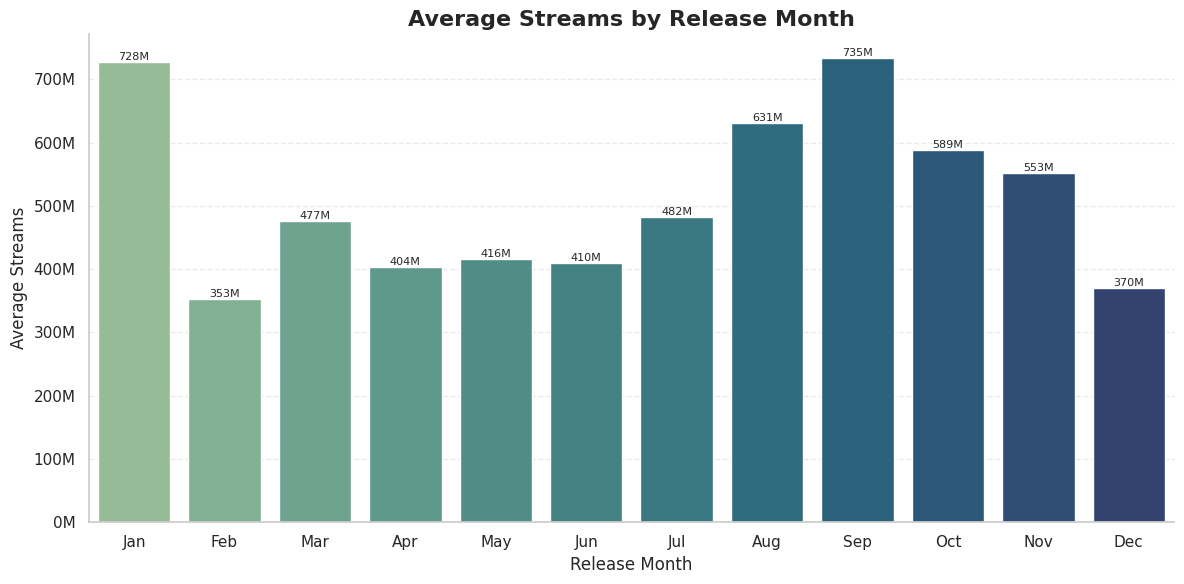

In [93]:
# Chart - 7 visualization code

# Average Streams by Release Month

month_streams = (
    df_clean.groupby("released_month")["streams"]
    .mean()
    .reset_index()
)

month_names = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr",
    5:"May", 6:"Jun", 7:"Jul", 8:"Aug",
    9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

month_streams["Month"] = month_streams["released_month"].map(month_names)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=month_streams,
    x="Month",
    y="streams",
    hue="Month",
    palette="crest",
    legend=False
)

plt.title(
    "Average Streams by Release Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Month", fontsize=12)
plt.ylabel("Average Streams", fontsize=12)

from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)

for container in ax.containers:
    labels = [f"{v.get_height()/1e6:.0f}M" for v in container]
    ax.bar_label(container, labels=labels, fontsize=8)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it provides a clear comparison of the average streams across different release months. Since months are discrete categories, the visualization makes it easy to identify seasonal patterns and determine whether songs released in certain months perform better on average.

##### 2. What is/are the insight(s) found from the chart?

* September records the highest average streams (735M), and the distribution indicates that this performance is supported by consistently strong-performing songs rather than being driven by a single exceptional hit.

* January also shows a very high average stream count (728M); however, its distribution reveals an extremely popular outlier, suggesting that the monthly average is influenced more heavily by one blockbuster release.

* The comparison highlights that release timing may contribute to streaming success, but the consistency of song performance differs across months. This reinforces earlier findings that popularity is shaped by multiple factors, including playlist exposure and artist recognition, rather than release timing alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis suggests that release timing can influence a song's streaming performance, with songs released in September and January achieving the highest average streams. In particular, September demonstrates consistently strong-performing songs, indicating that strategic release timing during certain periods may help artists and record labels maximize audience reach and improve promotional planning.

However, the findings also show that a high monthly average does not always represent consistent performance across all songs. January's average is influenced by one exceptionally successful track, highlighting that a few blockbuster releases can skew overall results. Therefore, release month alone should not be considered a guarantee of success, and it should be combined with factors such as playlist placement, artist popularity, and effective marketing strategies to achieve sustained streaming performance.

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12 Relationship Between Acousticness and Energy

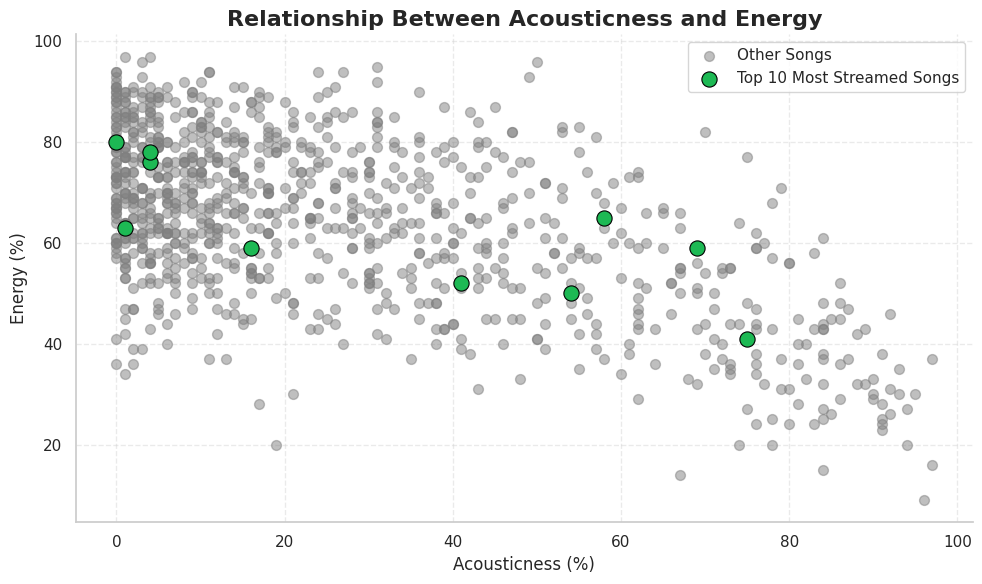

In [88]:
# Chart - 12 visualization code

# Relationship Between Acousticness and Energy

# Top 10 Most Streamed Songs
top10 = df_clean.nlargest(10, "streams")

plt.figure(figsize=(10,6))

# Plot all songs
plt.scatter(
    df_clean["acousticness_%"],
    df_clean["energy_%"],
    color="grey",
    alpha=0.5,
    s=50,
    label="Other Songs"
)

# Highlight Top 10 songs
plt.scatter(
    top10["acousticness_%"],
    top10["energy_%"],
    color="#1DB954",
    edgecolors="black",
    linewidth=0.8,
    s=120,
    label="Top 10 Most Streamed Songs"
)

plt.title(
    "Relationship Between Acousticness and Energy",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Acousticness (%)", fontsize=12)
plt.ylabel("Energy (%)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen because it is the most suitable visualization for examining the relationship between two continuous numerical variables. It helps identify patterns, trends, clusters, and potential correlations between acousticness and energy while highlighting the variation among individual songs.

##### 2. What is/are the insight(s) found from the chart?

* The scatter plot reveals a noticeable negative relationship between acousticness and energy, indicating that songs with higher acousticness generally tend to have lower energy levels.

* The top 10 most streamed songs are distributed across a wide range of acousticness values, but almost all maintain moderate to high energy levels (around 50–80%). This suggests that while acousticness varies among popular songs, higher energy is a more common characteristic.

* Comparing this chart with the earlier popularity analysis shows that there is no single audio profile that guarantees streaming success. Highly streamed songs differ in their acousticness, reinforcing the idea that popularity is influenced by a combination of musical attributes, artist recognition, playlist exposure, and audience preferences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis indicates that highly streamed songs generally maintain moderate to high energy levels, regardless of their acousticness. This insight can help artists, producers, and streaming platforms better understand listener preferences when creating songs, curating playlists, or developing recommendation systems.

At the same time, the wide distribution of the top streamed songs shows that successful music cannot be explained by acousticness and energy alone. As observed in the previous visualizations, factors such as playlist presence and artist popularity also contribute significantly to streaming performance. Therefore, combining musical characteristics with effective promotion and platform visibility is likely to produce better results than focusing on a single audio feature.

#### Chart - 13 Distribution of Musical Keys

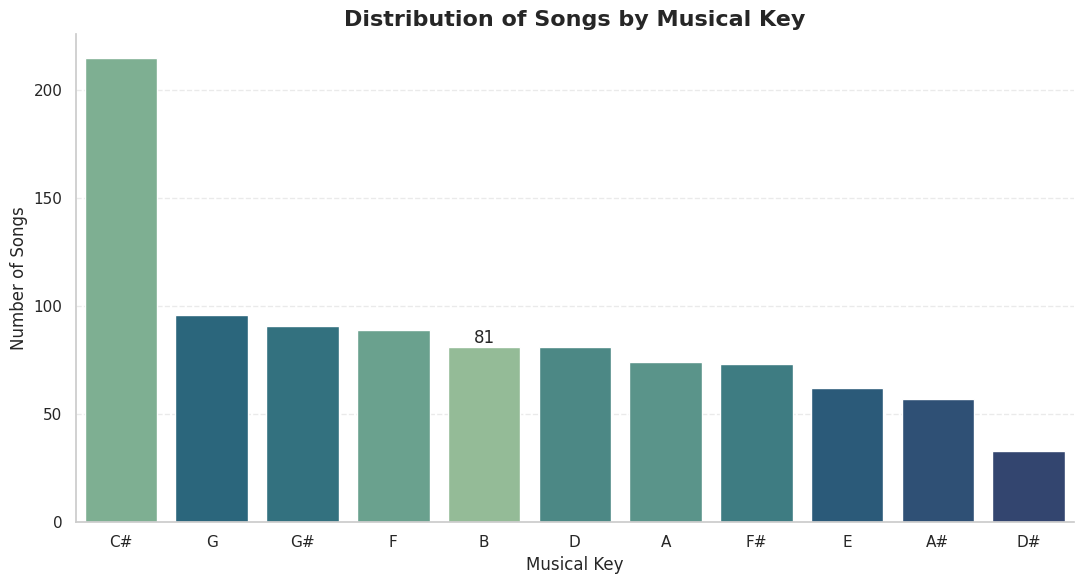

In [98]:
# chart 13 visualisation

# Distribution of Musical Keys

plt.figure(figsize=(11,6))

ax = sns.countplot(
    data=df_clean,
    x="key",
    hue="key",
    order=df_clean["key"].value_counts().index,
    palette="crest",
    legend=False
)

plt.title("Distribution of Songs by Musical Key", fontsize=16, fontweight="bold")
plt.xlabel("Musical Key")
plt.ylabel("Number of Songs")

ax.bar_label(ax.containers[0])

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because musical key is a categorical variable. It provides a clear comparison of the number of songs composed in each musical key, making it easy to identify the most and least frequently used keys in the dataset.

##### 2. What is/are the insight(s) found from the chart?

* **C#** is the most frequently used musical key in the dataset, with **over 200 songs**, making it significantly more common than any other key.

* Keys such as **G, G#, F, B, and D** also appear frequently, whereas **D#** is the least common, indicating that artists tend to prefer certain musical keys over others.

* The uneven distribution suggests that song composition is concentrated around a limited number of keys rather than being evenly spread across all available musical keys. This may reflect common vocal ranges, instrument tuning, or songwriting preferences within the music industry.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distribution of musical keys helps artists, producers, and music educators understand common composition patterns in contemporary music. Knowing which keys are most frequently used can support songwriting, arrangement, and playlist creation by aligning with established industry practices.

However, the chart does not establish any relationship between musical key and commercial success. A key being used more frequently does not necessarily mean it generates higher streams or greater listener engagement. Therefore, musical key should be considered as one aspect of composition rather than a direct indicator of a song's popularity.

#### Chart - 14 - Correlation Heatmap of Audio Features

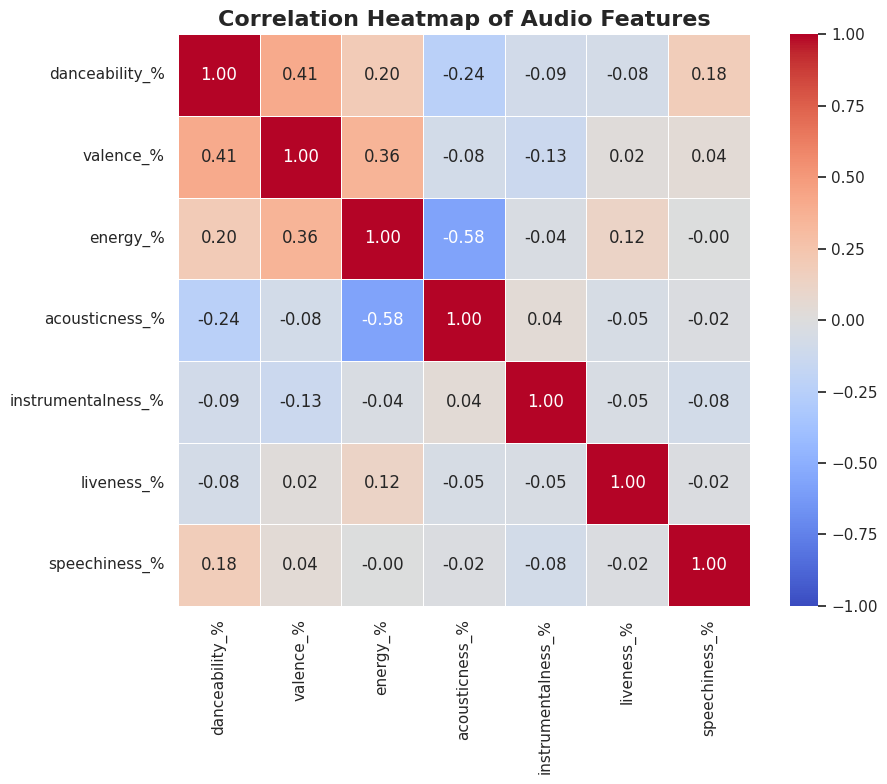

In [79]:
# chart 14 Visualisation code

# Correlation Heatmap of Audio Features

audio_features = [
    'danceability_%',
    'valence_%',
    'energy_%',
    'acousticness_%',
    'instrumentalness_%',
    'liveness_%',
    'speechiness_%'
]

corr = df_clean[audio_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Heatmap of Audio Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen because it provides a comprehensive view of the relationships between multiple numerical variables at the same time. It helps identify positive and negative correlations, making it easier to understand which factors are most closely associated with a song's streaming performance.

##### 2. What is/are the insight(s) found from the chart?


* Danceability and energy show a positive correlation, suggesting that more danceable songs also tend to be more energetic.
* Acousticness generally has a negative relationship with energy, indicating that highly acoustic songs are often less energetic.
* Instrumentalness has weak correlations with most other features, showing that instrumental content varies independently.
* Most audio features exhibit weak to moderate correlations, suggesting that each feature contributes a unique aspect to a song's overall characteristics.Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

In [ ]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***